# Analysing and Predicting Luxury Watch Prices 


## Skills: Introduction to Programming

In [49]:
#Import the relevant libraries for data manipulation and visualization and prediction:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import sklearn.linear_model as lg 
from pathlib import Path

#### Yannick Allmann, Jan Nemeth (add names)

## Part1: Dataset Loading 

In this section we will be loading the dataset of luxury watches we obtained from Kaggle. We will be using the pandas library to read the dataset and load it into a DataFrame for further analysis.


In [50]:
#Load the datset using the pandas library via Github
watch_data = pd.read_csv("Watches.csv")

#Inspect the first few rows of the dataset
watch_data.head()

C:\Users\allma\AppData\Local\Temp\ipykernel_51604\1283161374.py:2: DtypeWarning: Columns (13) have mixed types. Specify dtype option on import or set low_memory=False.
  watch_data = pd.read_csv("Watches.csv")


,Unnamed: 0,name,price,brand,model,ref,mvmt,casem,bracem,yop,cond,sex,size,condition
0,0,Audemars Piguet Royal Oak Offshore Chronograph...,"$43,500",Audemars Piguet,Royal Oak Offshore Chronograph,26237ST.OO.1000ST.01,NaN,NaN,NaN,2019,Unworn,Men's watch/Unisex,42 mm,NaN
1,1,Audemars Piguet Royal Oak Selfwinding\n39mm Bl...,"$71,500",Audemars Piguet,Royal Oak Selfwinding,15300ST.OO.1220ST.02,NaN,NaN,NaN,2012,Very good,Men's watch/Unisex,39 mm,NaN
2,2,Audemars Piguet Royal Oak Chronograph\nBlue Di...,"$79,191",Audemars Piguet,Royal Oak Chronograph,26331ST,Automatic,Steel,Steel,Unknown,Unworn,NaN,41 mm,NaN
3,3,Audemars Piguet Royal Oak Chronograph\nSelfwin...,"$108,000",Audemars Piguet,Royal Oak Chronograph,26715ST.OO.1356ST.01,Automatic,Steel,Steel,2022 (Approximation),New,Men's watch/Unisex,38 mm,NaN
4,4,Audemars Piguet Royal Oak Offshore Chronograph...,"$27,500",Audemars Piguet,Royal Oak Offshore Chronograph,26170ST.OO.1000ST.01,Automatic,Steel,Steel,Unknown,Very good,Men's watch/Unisex,42 x 54 mm,NaN


For the interested reader: ref stands for the reference number of the watch, movm stands for the movement of the watch, casem stands for the case material, bracem stands for the bracelet material, yop stands for the year of production, cond stands for the condition of the watch

Before we start with the cleaning lets descirbe the dataset to get an overview

In [51]:
watch_data.describe()

,Unnamed: 0
count,284491.000000
mean,16027.513369
std,17410.945197
min,0.000000
25%,4199.000000
50%,9211.000000
75%,20556.000000
max,72584.000000


#Add explantion later

## Part 2: Data Cleaning (Missing Values)

As our final goal in these project is to predict the price of the luxury watches we need a complete dataset without any missing values otherwise a machine learning model will not work well. Therefore, we will look at which columns have missing values in the dataset. After identifying the missing values, we will then decide how to handle these missing values, whether we will drop the rows with missing values or fill them with some appropriate values (e.g., mean-based, model-based imputation, etc.).

In [52]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

Unnamed: 0     0.000000
name          25.513988
price          0.142711
brand          0.046047
model         10.708950
ref           15.168142
mvmt          69.135755
casem         57.742073
bracem        61.476813
yop            0.047102
cond          26.709808
sex           33.675934
size           8.294463
condition     74.843141
dtype: float64

We can see that a lot of columns contain a significant amount of missing values, for example the columns condition and movement have roughly 70% missing values. Therefore, we have to make well-informed decisions on how to handle these missing values:

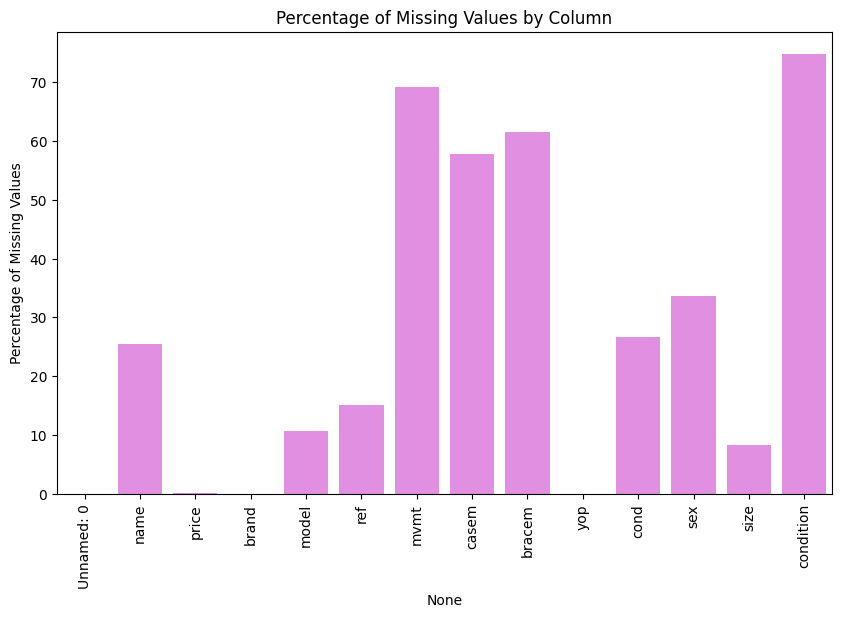

In [53]:
#To Visualize the percentage of missing values by column we can use a bar plot:
#We use seaborn for the bar plot and matplotlib for the figure size and labels
#The index of the missing_values series contains the column names (e.g. brand, model, etc.) and the values of the missing_values series contains the percentage of missing values for each column. T
#xticks refers to the x-axis labels and rotation=90 means that we rotate the labels by 90 degrees to make them more readable

plt.figure(figsize=(10,6))
sns.barplot(x=missing_values.index, y=missing_values.values, color='violet')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values by Column')
plt.show()

First of all since Unnamed: 0 is just an index column we will drop it from the dataset. 

In [54]:
#Drop the Unnamed:0 column
watch_data = watch_data.drop(columns=['Unnamed: 0'])

Since name is just a composite of the brand and the model of the watch we will also drop this column from the dataset since it does not provide any additional information for our analysis.

In [55]:
#Drop the name column 
watch_data = watch_data.drop(columns=['name'])

Next the reference numbers does not provide any  information for our analysis and contains missing values as well, therefore we will also drop this column from the dataset.
 

In [56]:
#Drop the reference column: 
watch_data = watch_data.drop(columns=['ref'])

Furthermore we can see that we have 2 condition columns in the dataset, cond and condition. In the original head, the cond contained information, while condition did not contain information (only NaNs). The cond column also has less NaNs, so we are tempted to delete the condition column. First we want to check if we dont lose any information from this however.

In [57]:
# Look for rows where 'cond' is NaN AND 'condition' is NOT NaN
risk_rows = watch_data[watch_data['cond'].isna() & watch_data['condition'].notna()]

print(f"Number of rows at risk of losing data: {len(risk_rows)}")
display(risk_rows[['cond', 'condition']].head())

Number of rows at risk of losing data: 71569


,cond,condition
151509,NaN,Very good
151510,NaN,Very good
151511,NaN,Very good
151512,NaN,Unworn
151513,NaN,Unworn


As you can see, we would actually lose over 70'000 Rows of information if we would delete this column, as it has information when the cond column does not. Next we want to check if we have an overlap of rows, where both columns have information but they are not the same.

In [58]:
# Look for rows where both have data, but the values don't match
conflict_rows = watch_data[watch_data['cond'].notna() & watch_data['condition'].notna() & (watch_data['cond'] != watch_data['condition'])]

print(f"Number of conflicting rows: {len(conflict_rows)}")

Number of conflicting rows: 0


As it turns out, we are in luck as there are no conflicting values. This means we can use data from either the cond and the condition column and they dont change the value, if there is a value. This menas we just add the condition column to the cond column if there is information in the Condition column but not the cond column. 

In [59]:
# Fill the NaNs in 'cond' with the values from 'condition'
watch_data['cond'] = watch_data['cond'].fillna(watch_data['condition'])


Now that we dont lose any information we can delete the condition column

In [60]:
# now it is perfectly safe to drop the 'condition' column
watch_data = watch_data.drop(columns=['condition'])

In [61]:
#Show the percentages of missing values by column in the dataset
missing_values = watch_data.isna().mean() * 100
missing_values

price      0.142711
brand      0.046047
model     10.708950
mvmt      69.135755
casem     57.742073
bracem    61.476813
yop        0.047102
cond       1.552949
sex       33.675934
size       8.294463
dtype: float64

We now only have missing values in 1.5% of the condition rows.

The next variables (e.g. movement and brace material ) need to be handled more carefully since they are really relevant for predicting watch priced but are also missing in a significant amount of rows. Therefore, we will be filling the missing values in these columns with the most frequent value in the respective column mapped by the name of the watch. For example, if a watch is a Royal Oak Chronograph and the movement is missing we will fill this missing value with the most frequent movement for Royal Oak Chronograph watches in the dataset. This way we can fill the missing values in a informed way and not just drop a lot of rows from the dataset which would lead to a significant loss of information. What we mean exactly by it in terms of code: 

In [62]:
#Lets create an example of the described logic: 

#Create a subset of the dataset (with boolean masking) where the model of the dataset contains only observations where the model is a Royal Oak Chronograph
royal_oak_data = watch_data[watch_data['model'] == 'Royal Oak Chronograph']

#With value_counts we can see the individual values in the movement column and how many times they occur in the dataset. 
royal_oak_data['mvmt'].value_counts()


mvmt
Automatic         835
Manual winding      2
Name: count, dtype: int64

In [63]:
#To get the most frequent value (since value_counts() is always sorted in descending order) we can use the index method to get the first value of the index which is the most frequent value in the movement column 
most_frequent_value = royal_oak_data['mvmt'].value_counts().index[0]
most_frequent_value

'Automatic'

We can see in this example that the overwelming majority of Royal Oak Chronograph watches in the dataset have a movement called "Automatic". Therefore, if we have a Royal Oak Chronograph watch with a missing value in the movement column we will fill this missing value with "Automatic". Lets see how many missing values we have in the movement in the royal oak chronograph subset of the dataset:

In [64]:
#Look at missing values
royal_oak_data['mvmt'].isna().sum()

np.int64(1345)

In [65]:
#Missing values before imputation (needed for the barplot later on)
missing_values_before =  watch_data.isna().mean() * 100
missing_values_before

price      0.142711
brand      0.046047
model     10.708950
mvmt      69.135755
casem     57.742073
bracem    61.476813
yop        0.047102
cond       1.552949
sex       33.675934
size       8.294463
dtype: float64

Great! With our logic we can fill in a lot of missing values in the movement and bracelet material column and therefore we can keep a lot of rows in the dataset which would have been dropped if we had just dropped all rows with missing values.

**We will generalize this log for all the different watch models in the dataset and fill the missing values in the movement, bracelet material, case material, condition, size and sex column with the most frequent values accordingly**

**Explanation of the imputation logic:**


1. We have to loop thorugh all the columns in which we want to fill the missing values (movement, bracelet material, case material, condition, size and sex

2. We have to use a second nested loop to loop thorugh all the different watch models in the dataset. The pandas unique function ensures us that we only look at uniqe models

3. We have to find the most freuqent value in the respective column for the respective model. We can do this by first filtering the dataset for the respective model and then using value_counts() to get the most frequent value. We can then use the index method to get the most frequent value itself as we did before. 
Additional information on 3: Since value_counts() could potentially return an empty series if all values in the respective column for the respective model are missing we have to make sure that we do not get an error in this case. Therefore we will assign the value counts function to a variable and will check the length of the variable before we ise the index method. If the legnth of the variable is 0 we will skip this observation and not go on with step 4 since there is no value to fill in. If the length is not 0 we will go on with step 4 

4. Finally, we have to fill the missing values in the respective column for the respective model with the most frequent value we obtained. This can be done with locating (loc in pandas) the respective rows (rows where the model is the respective model AND the respective column is missing) and then assigning the most frequent value to these rows

(Runs 1.30m)

In [66]:
for column in ['mvmt', 'bracem', 'casem', 'cond', 'size', 'sex']:

    for model in watch_data['model'].unique():
        counts = watch_data[watch_data['model'] == model][column].value_counts()

        if len(counts) == 0:
            continue 
        else:
            most_frequent_value = counts.index[0]
            watch_data.loc[(watch_data['model'] == model) & (watch_data[column].isna()), column] = most_frequent_value

Now lets look at the missing values in the dataset after we have done the imputation:

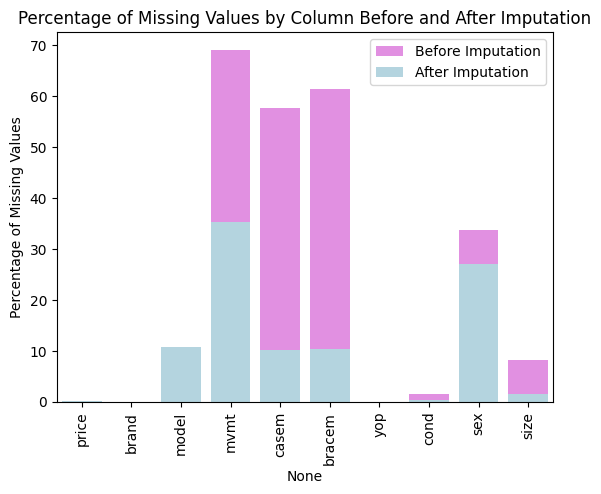

In [67]:
#Now lets look at the missing values in the dataset after we have done the imputation:
missing_values_after = watch_data.isna().mean() * 100
missing_values_after

#Plot the distribution of missing values after the imputation and before in as stacked bar chart to see the difference:
sns.barplot(x=missing_values_before.index, y=missing_values_before, color='violet', label='Before Imputation')
sns.barplot(x=missing_values_before.index, y=missing_values_after, color='lightblue', label='After Imputation')
plt.xticks(rotation=90)
plt.ylabel('Percentage of Missing Values')
plt.title('Percentage of Missing Values by Column Before and After Imputation')
plt.legend()
plt.show()

We can see for some values like movement, case material and bracelet material our approach worked pretty well and we have fewer missing values left, for approaches like condition and size we still have a lot of missing values left. We will decide what to do with these missing values in the next steps:

Since cond and sex have a similar percentage amount of missing values left we will look at how many observations have missing values in both columns: 

In [68]:
#Check how many observations that have missing values have missing values in the sex column and condition column:
#We do this by looking at the length of the subset of the dataset where bothsex and cond are missing (using boolean masking to filter the dataset for observations where both columns have missing values)

len(watch_data[(watch_data['sex'].isna()) & (watch_data['cond'].isna())])

729

729 have missing values in both columns. Since there is no meaningful way to get information about the condition and the sex of the watch for these observations we will drop all observations with missing values in these two columns from the dataset.

In [69]:
#The dropna function is used to drop rows with missing values in the specified columns (specified by argument subset).
watch_data = watch_data.dropna(subset=['sex', 'cond'])


In [70]:
#Check missing values again:
watch_data.isna().mean() * 100 

price      0.129979
brand      0.000000
model     11.720792
mvmt      11.234218
casem     11.297516
bracem    11.512536
yop        0.000966
cond       0.000000
sex        0.000000
size       1.464072
dtype: float64

Furthermore we can see that the columns model, mvmt, bracem and casem have similar numbers for missing values left. Therefore, we will also look at how many observations have missing values in all of these columns at the same time:

In [71]:
#Look at how many observations have missing values in the columns model, mvmt, bracem and casem at the same time:
#Same logic with boolean masking of the last step
len(watch_data[(watch_data['model'].isna()) & (watch_data['mvmt'].isna()) & (watch_data['bracem'].isna()) & (watch_data['casem'].isna())])  

23142

Again a significant amount of observations have missing values in all of these columns at the same time. Therefore, we will also drop all observations with missing values in these columns from the dataset since there will not be any meaningful way to get information about the model, movement, bracelet material and case material for these observations. .

In [72]:
#Drop the rows with missing values in the columns model, mvmt, bracem and casem:
watch_data = watch_data.dropna(subset=['model', 'mvmt', 'bracem', 'casem'])

In [73]:
#lets look at how many observations have missing values in the dataset again: 
watch_data.isna().mean() * 100

price     0.144170
brand     0.000000
model     0.000000
mvmt      0.000000
casem     0.000000
bracem    0.000000
yop       0.001096
cond      0.000000
sex       0.000000
size      0.000000
dtype: float64

We are left with roughly no missing values. The few cases were missing values are left we will drop entirely from the dataset 

In [74]:
#Drop the rows with missing values in the whole dataset: 
watch_data_cleaned = watch_data.dropna()

#Look at how many observations we have left 
len(watch_data_cleaned)

182160

In [75]:
#Finally, lets rename our variables to make them more intuitive and easier to work with:
#We can use the rename method from pandas for this 
watch_data_cleaned = watch_data_cleaned.rename(columns={'mvmt': 'movement', 'bracem': 'bracelet_material', 'casem': 'case_material', 'cond': 'condition'})

We can see that all of the variables are of the general type object. We can give them more specific datatypes (e.g. int, float, strings). Which we will do now: 



In [76]:
#For the numeric columns we have to be more precise for isntance look at size column unique values with pd.unique first: 
(watch_data_cleaned['price']).unique()

array(['$43,500', '$71,500', '$79,191', ..., '$20,068', '$32,108',
       '$53,813'], shape=(27880,), dtype=object)

We can see that we can not convert it to numeric unless we get rid of the "mm". 

In [77]:
pd.unique(watch_data_cleaned['size'])

array(['42 mm', '39 mm', '41 mm', ..., '41 x 10.75 mm', '40 x 10.75 mm',
       '46 x 17 mm'], shape=(4870,), dtype=object)

## Part 3: Data Cleaning (Datatypes)

**Datatypes of the variables in the dataset:**

In [78]:
#Overview of the datatypes of the variables in the dataset after cleaning:
watch_data_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 182160 entries, 0 to 284490
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   price              182160 non-null  object
 1   brand              182160 non-null  object
 2   model              182160 non-null  object
 3   movement           182160 non-null  object
 4   case_material      182160 non-null  object
 5   bracelet_material  182160 non-null  object
 6   yop                182160 non-null  object
 7   condition          182160 non-null  object
 8   sex                182160 non-null  object
 9   size               182160 non-null  object
dtypes: object(10)
memory usage: 15.3+ MB


With pandas info() function we can get an overview of the datatypes of the variables in the dataset. Note that object is the general datatype for string variables in pandas. For the numeric columns like price, size and year of production we will convert them to numeric datatypes (e.g. int or float). But lets first inspect the unique values of this features to see if there are any issues with the datatypes 

In [79]:
#Unique values of the size column:
watch_data_cleaned['size'].unique()


array(['42 mm', '39 mm', '41 mm', ..., '41 x 10.75 mm', '40 x 10.75 mm',
       '46 x 17 mm'], shape=(4870,), dtype=object)

We can see that after the numeric size the mm is added to the values. Therefore we will slice the size column to keep only the first 2 characters (so the real size) and then convert it to numeric.

In [29]:
#Lets keep only the first 2 characters of the size column to get rid of the "mm" and then convert it to numeric:
#Slice the size column to keep only the first 2 characters using the str 
#To prevent that this code does not break coerce will set any non-numeric values to NaN instead of throwing an error.

watch_data_cleaned['size'] = watch_data_cleaned['size'].str[:2]
watch_data_cleaned['size'] = pd.to_numeric(watch_data_cleaned['size'], errors='coerce')

In [30]:
watch_data_cleaned['yop'].unique()



array(['2019', '2012', 'Unknown', '2022 (Approximation)',
       '2018 (Approximation)', '2016 (Approximation)', '2015', '2016',
       '2022', '2021', '2014', '2018', '2017', '2020', '2023',
       '2021 (Approximation)', '2005', '2003 (Approximation)',
       '2020 (Approximation)', '2006', '2002', '2004', '1994', '2013',
       '2019 (Approximation)', '2023 (Approximation)', '2007',
       '2017 (Approximation)', '1986', '2010', '2008', '2011',
       '1997 (Approximation)', '1990 (Approximation)',
       '2012 (Approximation)', '1977', '2003', '1999 (Approximation)',
       '2010 (Approximation)', '1990', '2009 (Approximation)', '2009',
       '1976 (Approximation)', '2000', '2004 (Approximation)', '1989',
       '1980', '1982', '1975', '2005 (Approximation)',
       '1980 (Approximation)', '2000 (Approximation)',
       '2002 (Approximation)', '1993', '1999', '1997',
       '1995 (Approximation)', '1970', '1996', '1998 (Approximation)',
       '1995', '1998', '1996 (Approximation)

The same logic applies here for the year of production. We are interested in the first 4 numeric year characters of the strin. Therefore we will slice the year of production column to keep only the first 4 characters and then convert it to numeric. 

In [31]:
#Lets keep only the first 4 characters of the year of production column
#We use coerce to set any non-numeric values to NaN instead of throwing an error.

watch_data_cleaned['yop'] = watch_data_cleaned['yop'].str[:4]
watch_data_cleaned['yop'] = pd.to_numeric(watch_data_cleaned['yop'], errors='coerce')

Next we will look at the unique values of the price column to see if there are any issues with the datatypes in this column as well.

In [32]:
#Unique values of the price column:
watch_data_cleaned['price'].unique()

array(['$43,500', '$71,500', '$79,191', ..., '$20,068', '$32,108',
       '$53,813'], dtype=object)

In [33]:
#To convert the variable price to numeric we do have to get rid of the "$"  in front of the values. 
#Furthermore we have to get rid of the "," in the values as well since it this is not a numeric character in python. 
# Therefore we will slice the price column to keep only the characters from the 2nd character on to get rid of the "$" 
# and then we will replace the "," with an empty string and then convert it to numeric.

watch_data_cleaned['price'] = watch_data_cleaned['price'].str[1:] 

#Use the string replace method to replace the "," with an empty string in the price column
watch_data_cleaned['price'] = watch_data_cleaned['price'].str.replace(',', '')

#Convert the price column to numeric, again coerce the error
watch_data_cleaned['price'] = pd.to_numeric(watch_data_cleaned['price'], errors='coerce')

In [34]:
watch_data_cleaned.dtypes

price                float64
brand                 object
model                 object
movement              object
case_material         object
bracelet_material     object
yop                  float64
condition             object
sex                   object
size                 float64
dtype: object

After we converted the corresponding numeric columns we have to get rid of the missing values that we initiated with coerce when we converted the size, year of production and price to numeric. 

In [35]:
#Drop all reamining missing values 
watch_data_cleaned = watch_data_cleaned.dropna()

# Display length of the remaining dataset after dropping missing values:
len(watch_data_cleaned)

110237

**We are stil left with 110237 observations**

In [36]:
watch_data_cleaned

,price,brand,model,movement,case_material,bracelet_material,yop,condition,sex,size
0,43500.0,Audemars Piguet,Royal Oak Offshore Chronograph,Automatic,Steel,Rubber,2019.0,Unworn,Men's watch/Unisex,42.0
1,71500.0,Audemars Piguet,Royal Oak Selfwinding,Automatic,Steel,Steel,2012.0,Very good,Men's watch/Unisex,39.0
3,108000.0,Audemars Piguet,Royal Oak Chronograph,Automatic,Steel,Steel,2022.0,New,Men's watch/Unisex,38.0
5,41000.0,Audemars Piguet,Royal Oak Offshore Diver,Automatic,Steel,Rubber,2018.0,Unworn,Men's watch/Unisex,42.0
6,43500.0,Audemars Piguet,Royal Oak Offshore Diver Chronograph,Automatic,Steel,Rubber,2016.0,Very good,Men's watch/Unisex,42.0
...,...,...,...,...,...,...,...,...,...,...
284486,9790.0,Zenith,Defy El Primero,Automatic,Titanium,Rubber,2022.0,Very good,Men's watch/Unisex,44.0
284487,8450.0,Zenith,Chronomaster Sport,Automatic,Steel,Steel,2021.0,Very good,Men's watch/Unisex,41.0
284488,16500.0,Zenith,El Primero,Automatic,Steel,Steel,2019.0,Very good,Men's watch/Unisex,38.0
284489,9000.0,Zenith,Chronomaster Sport,Automatic,Steel,Steel,2021.0,Unworn,Men's watch/Unisex,41.0


## Part 4: Exploratory Data Analysis (EDA)

### 4.1. Price Variable

In this section we want to understand our dataset better and get some insights about the distribution and relationships of variables in the dataset in order to understand if we need to apply any transformations or if there are any outliers that might affect our model. First of all we will look at the distribution of the price variable since this is our main target variable 

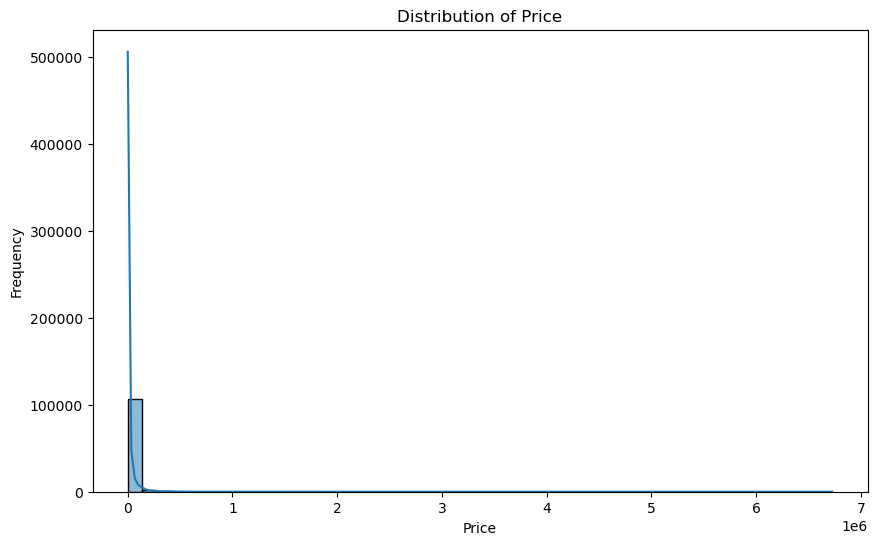

In [37]:
#To plot the distribution of the price variable we use the seaborn library and the histplot function to plot a histogram of the  price variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['price'], bins=50, kde=True)
plt.title('Distribution of Price')
plt.xlabel('Price') 
plt.ylabel('Frequency')
plt.show()

We can see that the distribution of the price variable is highly right skewed (driven by really expensive outliers) and not normally distributed. Our basic statistics and data science knowledge tells us that a log transformation could potentialy bring the distribution closer to a normal distribution. Lets try this out: 

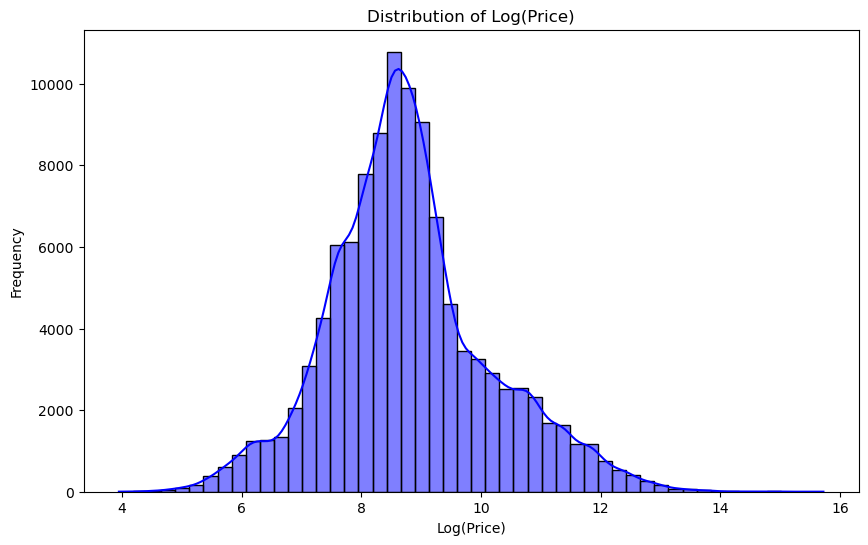

In [38]:
#Distribution of the log price variable:
#np.log is a numpy function that applies the natural logarithm to the values in the price column. 

plt.figure(figsize=(10,6))
sns.histplot(np.log(watch_data_cleaned['price']), bins=50, kde=True, color='blue')
plt.title('Distribution of Log(Price)')
plt.xlabel('Log(Price)')
plt.ylabel('Frequency')
plt.show()

We can see that the log price is having a better approximation to a normal distribution than the price variable. Therefore, we will be using the log price as our target variable for the prediction task in this project.

Furthermore, we are interested into the price ranges of our dataset. For this we will group the dataset according to 3 categories of price ranges (low, medium and high) and look at a bar plot to see how many observations we have in each price range category.



/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_20956/550754566.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=categories, y=counts, palette='viridis')


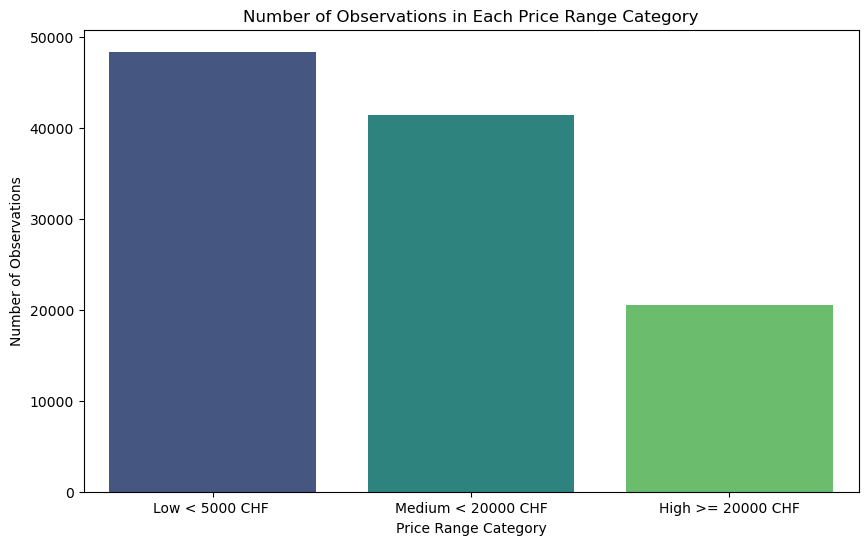

In [39]:
#Define 3 ctaegories in the dataset by filter with boolen masking according to the price variable:
#For the medium category we have to use the & operator to combine the two conditions for the price variable (price < 20000 and price >= 5000) 


category_low = watch_data_cleaned[watch_data_cleaned['price'] < 5000]
category_medium = watch_data_cleaned[(watch_data_cleaned['price'] < 20000) & (watch_data_cleaned['price'] >= 5000)]
category_high = watch_data_cleaned[watch_data_cleaned['price'] >= 20000]


#plot the categories in a bar plot to see how many observations we have in each price range category:
#To do this we will create a list of the categories and a list of the counts (with length function) of observations in each category
#Then we use the seaborn barplot function to plot the categories on the x-axis and the counts on the y-axis.

categories = ['Low < 5000 CHF ', 'Medium < 20000 CHF', 'High >= 20000 CHF']
counts = [len(category_low), len(category_medium), len(category_high)]
plt.figure(figsize=(10,6))
sns.barplot(x=categories, y=counts, palette='viridis')
plt.title('Number of Observations in Each Price Range Category')
plt.xlabel('Price Range Category')
plt.ylabel('Number of Observations')
plt.show()

We can see that most of oour dataset is concentrated in the low category. There are also a signficant amount of observations in the medium category and a smaller amount of observations in the high category. This is important to know for our prediction task since it means that our model will have more data to learn from in the low/medium price range than in the high price range. 

### 4.2. Brand Variable

Next up, we are interested in the distribution of the brand variable in our dataset. For this we will look at a bar plot to see how many observations we have for each brand in the dataset.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_20956/2025809084.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=unique_brands.index, y=unique_brands.values, palette='viridis')


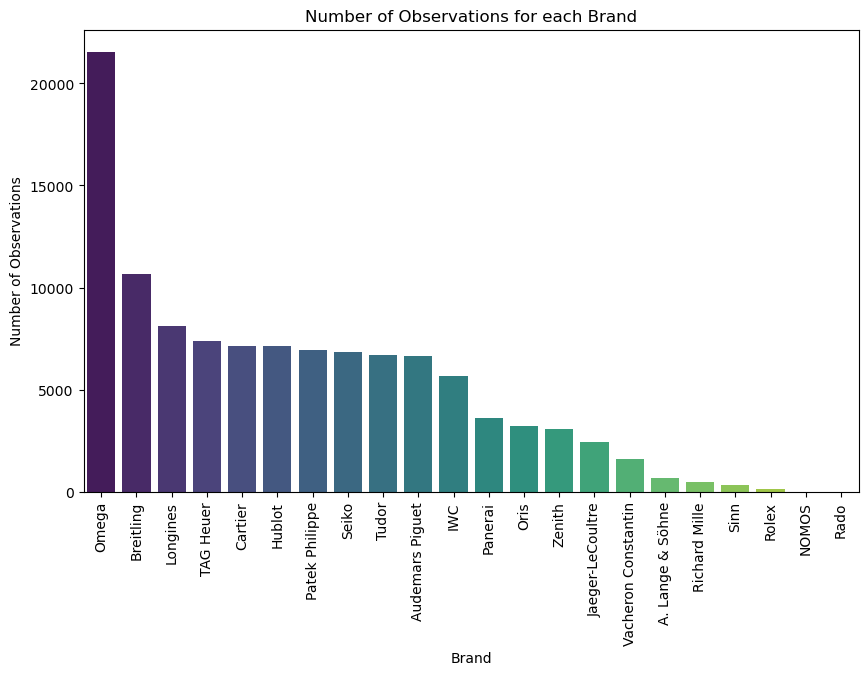

In [40]:
#With value_counts we get the nunique brand names as well as the occurence of each brandname 

unique_brands = watch_data_cleaned['brand'].value_counts()


#We will plot the unique brands using the index attribute for the name of the brands as the .values attribute for the corresponding occurence 
#Seaborn barplot is used for the barplot
#We rotate the labels on the x-axis by 90 degrees to make them more readable 

plt.figure(figsize=(10,6))
sns.barplot(x=unique_brands.index, y=unique_brands.values, palette='viridis')
plt.title('Number of Observations for each Brand')
plt.xlabel('Brand')
plt.xticks(rotation=90)
plt.ylabel('Number of Observations')
plt.show()


Most of our dataset is concetrated on the Omega brand, but Breitling and Longines have also a significant amount of observations in the dataset. Surprisingly, we have a low amount of observations in the Rolex brand as well, which is interesting since Rolex is one of the most popular luxury watch brands in the world.

### 4.3. Model Variable

Next we will look at the the most common watch models in our dataset. For this we will again at the value counts of the model variable.

/var/folders/kz/cdns3q5j33910y0dt9d7416m0000gn/T/ipykernel_20956/837524898.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=models.index, y=models.values, palette='viridis')


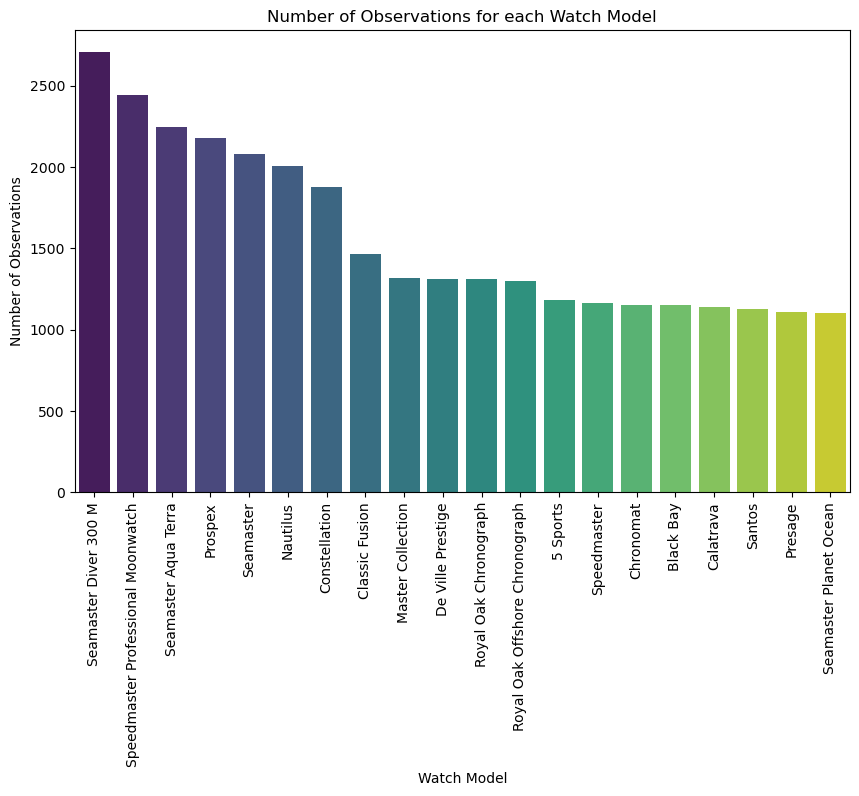

In [41]:
#First of all we again apply the previously described value_counts method 
#Since value counts sorts in descending order with .head(20) we can get the 20 most common watch models in our dataset.
models = watch_data_cleaned['model'].value_counts().head(20)

#We again plot the most common watch models in our dataset using the index attribute for the name of the models as the .values attribute for the corresponding occurence
#Seaborn barplot is used for the barplot
plt.figure(figsize=(10,6))
sns.barplot(x=models.index, y=models.values, palette='viridis') 
plt.title('Number of Observations for each Watch Model')
plt.xlabel('Watch Model')
plt.xticks(rotation=90)
plt.ylabel('Number of Observations')
plt.show()

The most common models stem from the Seamaster and Speedmaster Series of the Omega brand. Which is not surprising since we have the most observations from the Omega brand in our dataset.

### 4.4. Correlation between Variables 

**Size vs log(price)**

In this section we are interested in the relationship between different variables in our dataset. For visualizing the relationship between the different variables we will be using scatter plots for numeric variables.

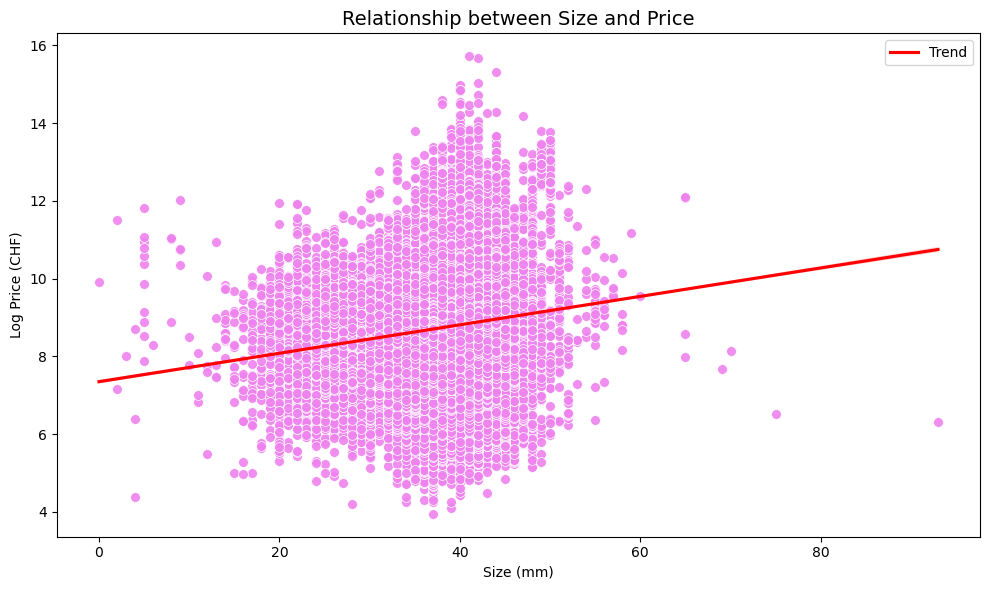

In [42]:
#Plot the relationship between log price and size with a scatter plot:


plt.figure(figsize=(10, 6))

#Scatterplot of size and log price:
# The x-axis of the scatter plot is the size variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.scatterplot(x=watch_data_cleaned['size'], y=np.log(watch_data_cleaned['price']), 
                color='violet', alpha=0.9, s=50)


#Regression Line with seaborn regplot function:
#The x-axis of the regression line is the size variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.regplot(x=watch_data_cleaned['size'], y=np.log(watch_data_cleaned['price']), 
            scatter=False, color='red', label='Trend')


plt.title('Relationship between Size and Price', fontsize=14)
plt.xlabel('Size (mm)')
plt.ylabel('Log Price (CHF)')
plt.legend()
plt.tight_layout()
plt.show()

Larger watch sizes tend to command higher prices, as shown by the positive trend line.Larger watch sizes tend to command higher prices, as shown by the positive trend line. However, the wide spread of points indicates that size alone is a weak predictor of price, suggesting other factors like brand and material play a more significant role. For modeling, this implies that size should not be used as a standalone feature but rather in combination with other variables to improve predictive power (as done in our project)

**Year of production vs log(price)**

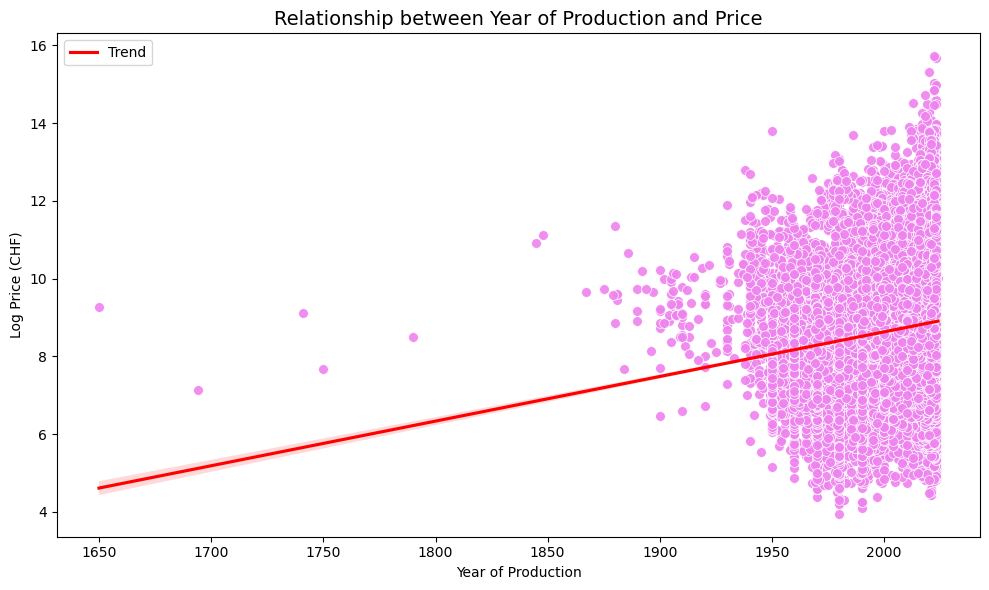

In [43]:
#Plot the relationship between log price and year of production with a scatter plot:


plt.figure(figsize=(10, 6))

#Scatterplot of yop and log price:
# The x-axis of the scatter plot is the yop variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.scatterplot(x=watch_data_cleaned['yop'], y=np.log(watch_data_cleaned['price']), 
                color='violet', alpha=0.9, s=50)


#Regression Line with seaborn regplot function:
#The x-axis of the regression line is the yop variable from the cleaned dataset and the y-axis is the log of the price variable from the cleaned dataset.
sns.regplot(x=watch_data_cleaned['yop'], y=np.log(watch_data_cleaned['price']), 
            scatter=False, color='red', label='Trend')


plt.title('Relationship between Year of Production and Price', fontsize=14)
plt.xlabel('Year of Production')
plt.ylabel('Log Price (CHF)')
plt.legend()
plt.tight_layout()
plt.show()

While more recent watches tend to fetch higher prices overall as shown by the positive trend line, the outliers before 1900 reaching log prices above regression line reveal that rare vintage and antique pieces can also command very high prices. As standalone year of production is likely a weak predictor of price 

**brand vs log(price)**

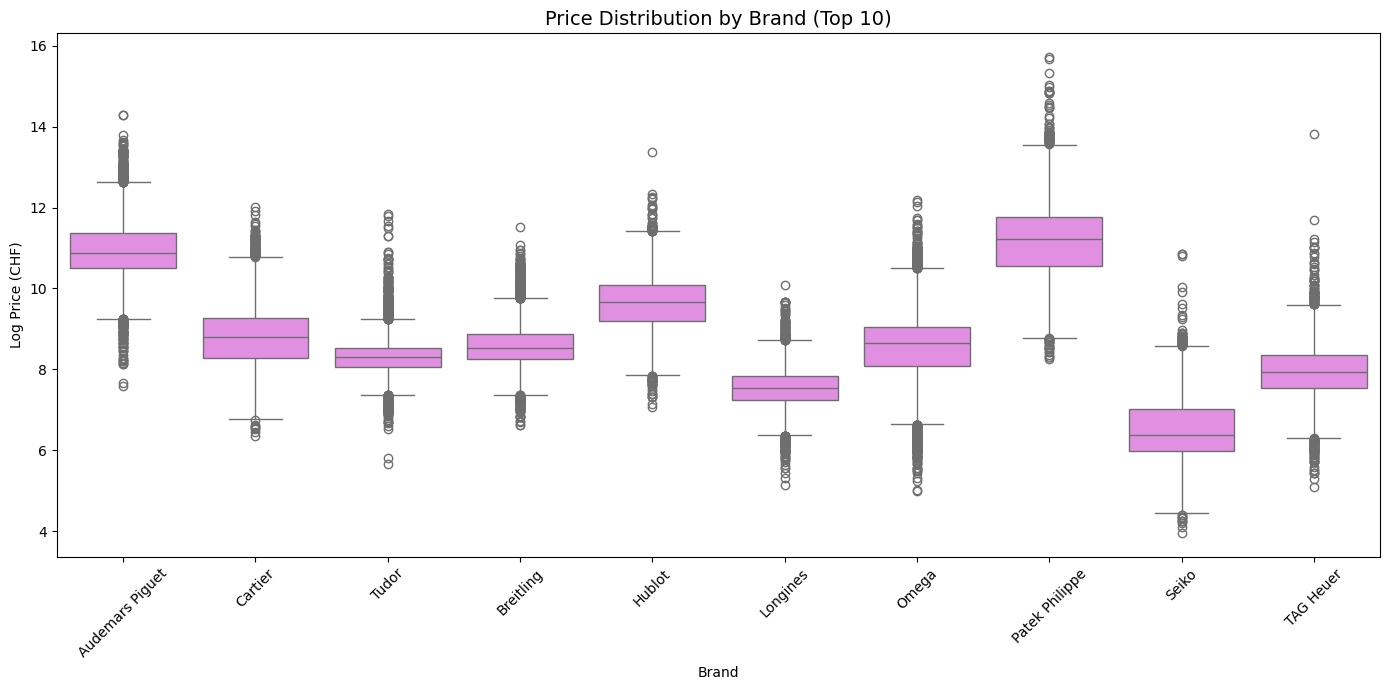

In [44]:
#We will look a the relationship between the price variable and the brand variable with a boxplot:
#First of all we get the top 10 most common brands in our dataset with value_counts and head(10) 
top_10_brands = watch_data_cleaned['brand'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common brands in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['brand'].isin(top_10_brands)], 
            x='brand', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Brand (Top 10)', fontsize=14)
plt.xlabel('Brand')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

Patek Philippe and Audemars Piguet clearly occupy the ultra-luxury segment with the highest median prices and wide distributions, while Seiko and Longines sit at the more accessible end of the spectrum. The large spread within most brands indicates that even within a single brand, price varies enormously depending on the model and condition, confirming that brand alone is a strong but insufficient predictor of price.

**case and bracelet material vs log(price)**

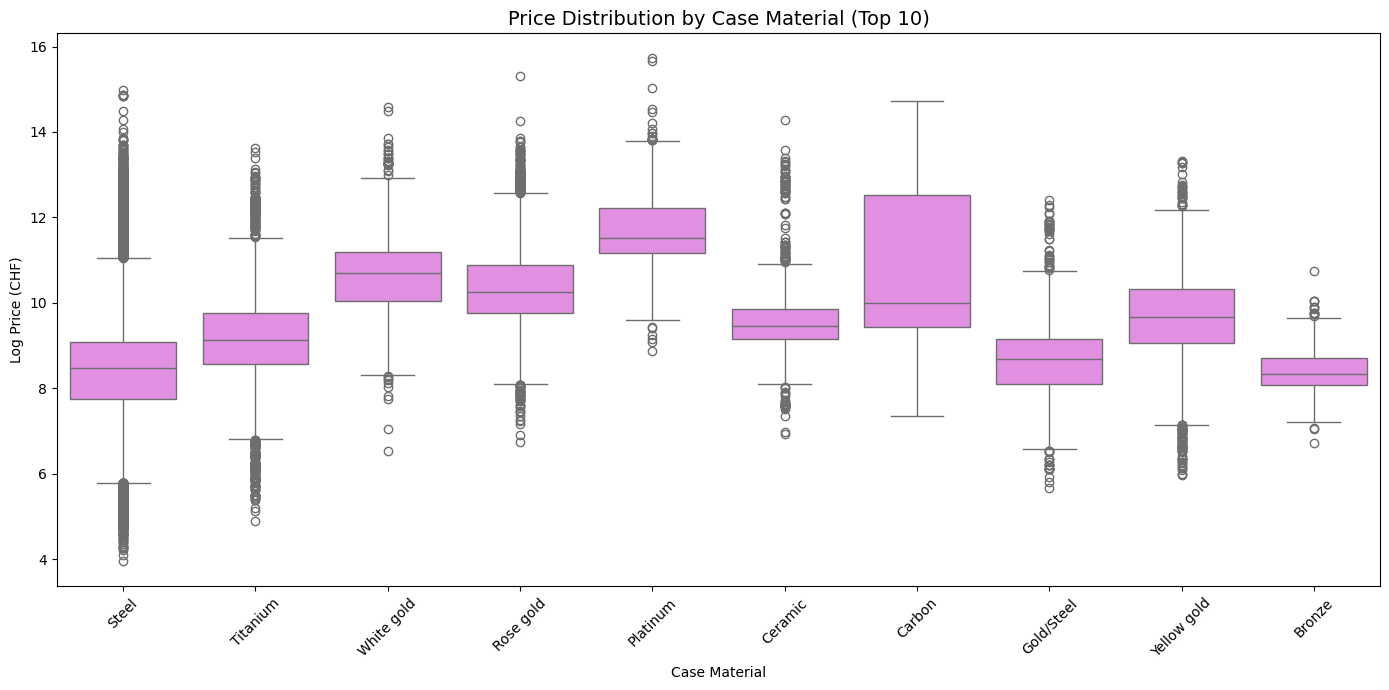

In [45]:
#We will look a the relationship between the price variable and the case_material variable with a boxplot:
#First of all we get the top 10 most common case materials in our dataset with value_counts and head(10) 
top_10_case_materials = watch_data_cleaned['case_material'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common case materials in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['case_material'].isin(top_10_case_materials)], 
            x='case_material', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Case Material (Top 10)', fontsize=14)
plt.xlabel('Case Material')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

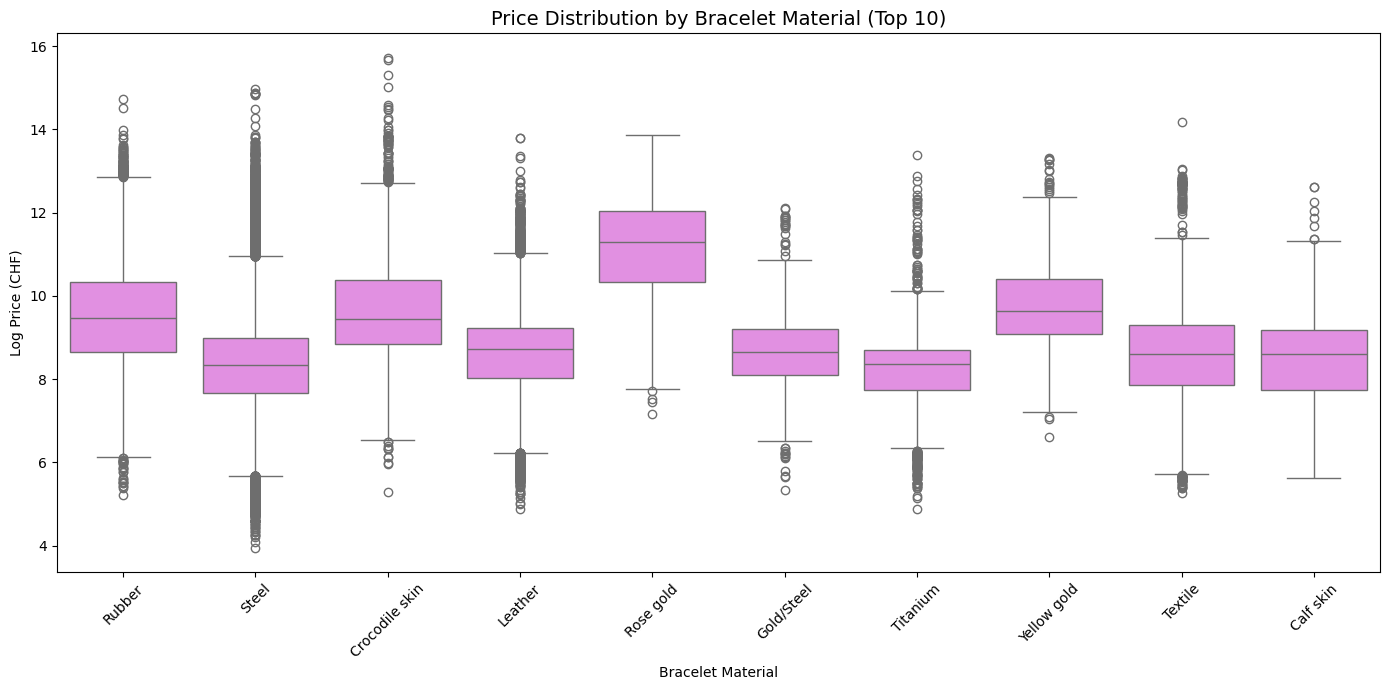

In [46]:
#We will look a the relationship between the price variable and the bracelet_material variable with a boxplot:
#First of all we get the top 10 most common bracelet materials in our dataset with value_counts and head(10) 
top_10_bracelet_materials = watch_data_cleaned['bracelet_material'].value_counts().head(10).index


#Boxplot using seaborn boxplot function:
#isin is used to filter the dataset for the top 10 most common bracelet materials in our dataset 
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned[watch_data_cleaned['bracelet_material'].isin(top_10_bracelet_materials)], 
            x='bracelet_material', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Bracelet Material (Top 10)', fontsize=14)
plt.xlabel('Bracelet Material')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

**Case Material:** Precious metals like platinum, white gold and rose gold command significantly higher median prices than steel, which despite being the most common material spans a very wide price range. This confirms that case material is a strong price signal and will likely be a valuable feature in modeling.

**Bracelet Material:** Rose gold bracelets stand out with the highest median price, while steel and titanium sit at the lower end. Interestingly the differences between bracelet materials are less pronounced than for case materials,

**Condition vs log(price)**

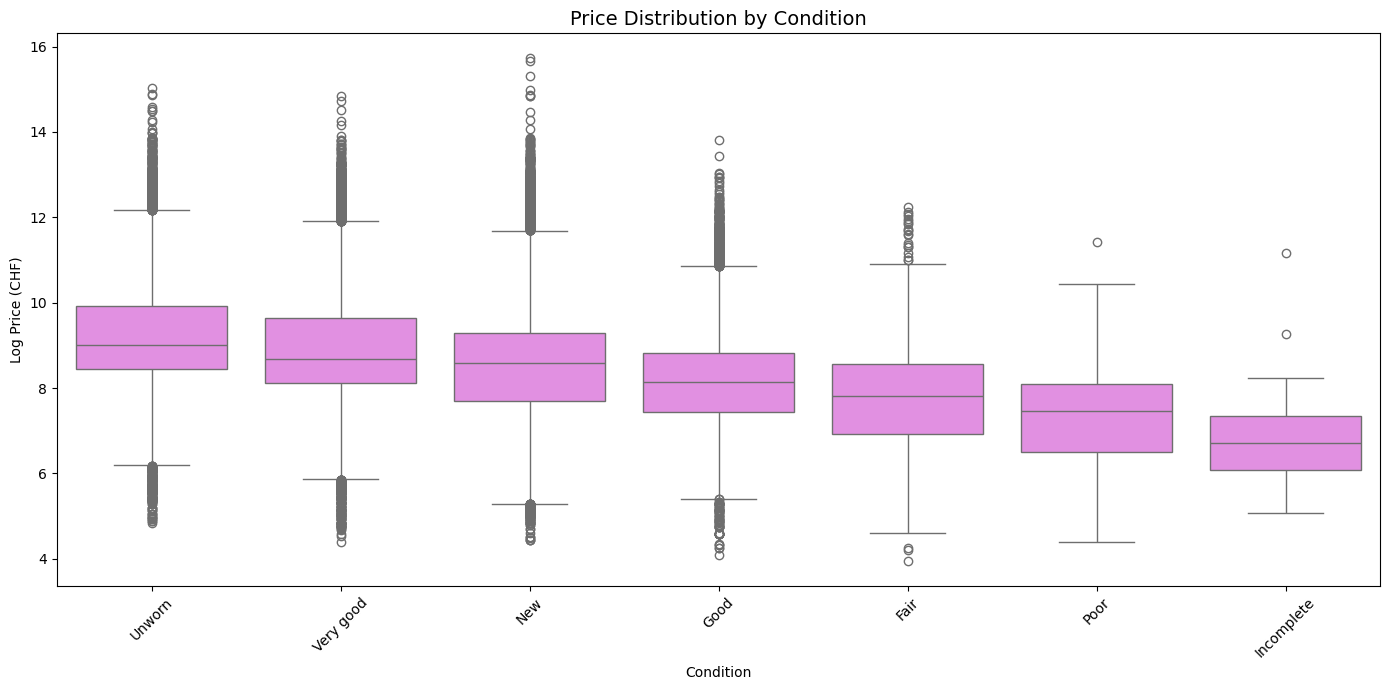

In [47]:
#Boxplot using seaborn boxplot function:
#Condition has only 7 different values in the dataset so we do not have to filter for the top 10 most common conditions in our dataset
#Rotate the labels on the x-axis by 45 degrees to make them more readable

plt.figure(figsize=(14, 7))
sns.boxplot(data=watch_data_cleaned,
            x='condition', y=np.log(watch_data_cleaned['price']), color='violet')
plt.xticks(rotation=45)
plt.title('Price Distribution by Condition', fontsize=14)
plt.xlabel('Condition')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

Even if new watches seem to have a similar price to "Very Good" watches, the overall trend is clear and consistent with market expectations that better condition correlates with higher prices. This suggests that condition should be included as a key feature in our model

## Part 5: Data Preprocessing

In this section we preprocess some finds that we made in the EDA section. For example, we will apply the log transformation to the price variable. Furthermore, we will look at the distribution of the other two numeric columns (size, and year of production) and apply transformations if necessary:

In [48]:
#Transform the price variable with a log transformation
watch_data_cleaned['log_price'] = np.log(watch_data_cleaned['price'])

#Afterwards, we can drop the normal price variable since we have the log price variable now: 
watch_data_cleaned = watch_data_cleaned.drop(columns=['price'])

Next we will look at the distribution of the size variable to see if we need to apply any transformations to this variable.



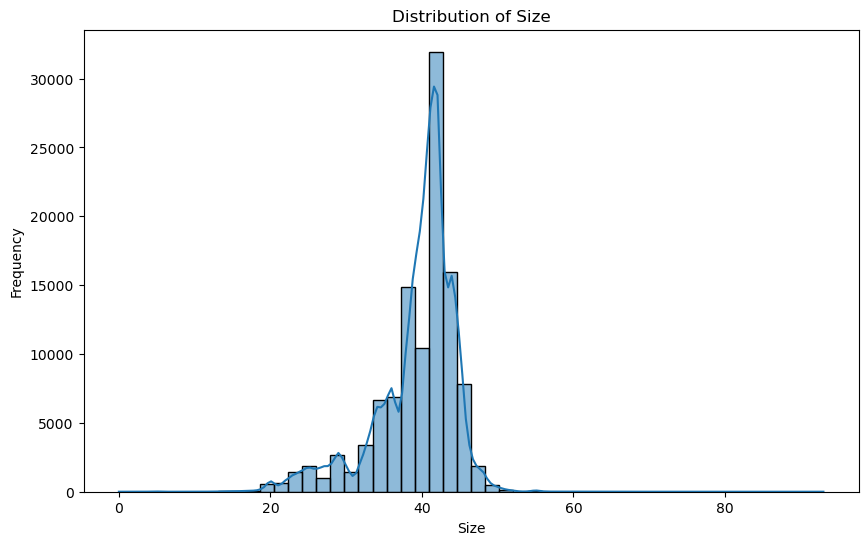

In [49]:
#To plot the distribution of the size variable we use the seaborn library and the histplot function to plot a histogram of the  size variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['size'], bins=50, kde=True)
plt.title('Distribution of Size')
plt.xlabel('Size') 
plt.ylabel('Frequency')
plt.show()

It looks roughly bell-shaped. Therefore, we will not apply a log transformations to the size. However for prediction purposes we will be using the standardized version of the size variable since it is on a different scale than the other variables in the dataset and this could affect the performance of our model. Therefore, we will be using the StandardScaler from sklearn to standardize the size variable:

In [53]:
#Standardscaler
scaler = StandardScaler()

#Apply the standard scaler to the size variable and create a new column with the scaled size variable 
watch_data_cleaned['size_scaled'] = scaler.fit_transform(watch_data_cleaned[['size']])

#Drop the existing size variable since we have the scaled size variable now:
watch_data_cleaned = watch_data_cleaned.drop(columns=['size'])

Next we will look at the distribution of the year of production  to see if we need to apply any transformations to this variable.


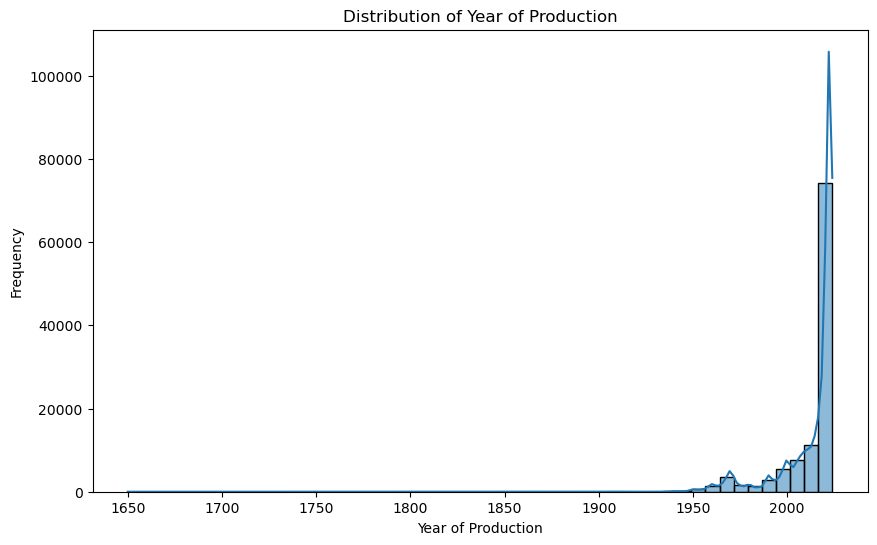

In [50]:
#To plot the distribution of the year of production variable we use the seaborn library and the histplot function to plot a histogram of the  year of production variable.
plt.figure(figsize=(10,6))
sns.histplot(watch_data_cleaned['yop'], bins=50, kde=True)
plt.title('Distribution of Year of Production')
plt.xlabel('Year of Production') 
plt.ylabel('Frequency')
plt.show()

Highly left skewed with a long tail of older watches. A look transformation will not help us here since the log works best for right skewed data. Therefore we will follow another approach: 

We will create a new variable called yop_category which will categorize the year of production into different categories (e.g. vintage, modern, 1980s, 2000s, 2010s, 2020s) based on the year of production. The pd.cut function allows us to do this in a very easy way by defining the bins (the boundaries for each category) and the labels for the categories.


In [51]:
#pd.cut splits the year of production variable into discrete buckets based on the defined bin boundaries, assigning each watch to an category:
 
watch_data_cleaned['yop_category'] = pd.cut(watch_data_cleaned['yop'], 
                                             bins=[0, 1980, 2000, 2010, 2020, 2030],
                                             labels=['Vintage', '1980s', '2000s', '2010s', '2020s'])

#Since we will use the year of production category variable for our prediction task we can drop the original year of production: 
watch_data_cleaned = watch_data_cleaned.drop(columns=['yop'])

The binning transformed a heavily skewed numeric variable with sparse data before 1980 into five meaningful era categories. We can also see this in the boxplot:

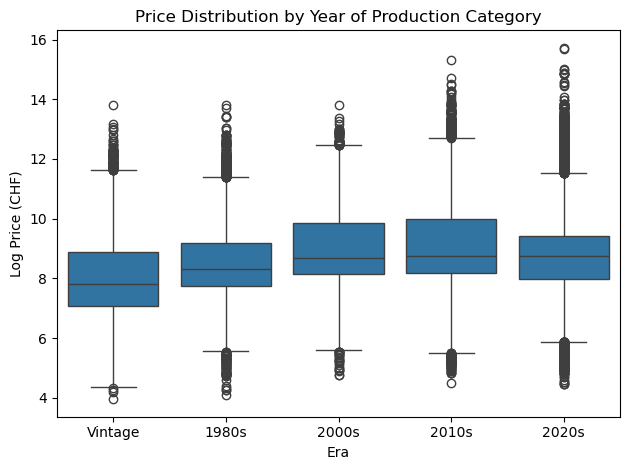

In [52]:
#Boxplot for the log(price) distribution by year of production category:
#Use seaborn boxplot function:

sns.boxplot(data=watch_data_cleaned, x='yop_category', y='log_price')
plt.title('Price Distribution by Year of Production Category')
plt.xlabel('Era')
plt.ylabel('Log Price (CHF)')
plt.tight_layout()
plt.show()

## Part 6: Prediction via Linear Regression

## Part 7: Data Visualization

## Part 7: Streamlit